**Lab Assignment - 6 : Feature Extraction and Machine Learning with Image and Text Data**

**1: Feature Extraction, Training, and Artifact Saving (train.py)**

In [5]:
import os
import time
import joblib
import cv2
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Define dataset paths matching your directory structure
DATASET_DIRS = {
    'Cracks': 1,      # Class 1: Crack
    'NonCracks': 0    # Class 0: Non-Crack
}
IMG_SIZE = (224, 224)

def extract_features_from_image(img_path):
    # 1. Read image with OpenCV
    img = cv2.imread(img_path)
    if img is None:
        return None
    
    # Inspect dimensions/channels
    h, w, c = img.shape
    
    # Resize to common size
    resized_img = cv2.resize(img, IMG_SIZE)
    
    # Create grayscale representation
    gray = cv2.cvtColor(resized_img, cv2.COLOR_BGR2GRAY)
    
    # 2. Extract numerical intensity statistics using NumPy
    total_pixels = gray.size
    mean_brightness = float(np.mean(gray))
    contrast = float(np.std(gray))
    
    # Dark pixels: threshold < 60; Bright pixels: threshold > 190
    dark_pixel_ratio = float(np.sum(gray < 60) / total_pixels)
    bright_pixel_ratio = float(np.sum(gray > 190) / total_pixels)
    
    median_val = float(np.median(gray))
    min_val = float(np.min(gray))
    max_val = float(np.max(gray))
    
    # 3. OpenCV Canny Edge Detection
    # Using adaptive thresholds based on median brightness
    sigma = 0.33
    lower_thresh = int(max(0, (1.0 - sigma) * median_val))
    upper_thresh = int(min(255, (1.0 + sigma) * median_val))
    
    edges = cv2.Canny(gray, lower_thresh, upper_thresh)
    edge_pixel_count = int(np.count_nonzero(edges))
    edge_density = float(edge_pixel_count / total_pixels)
    
    return [
        mean_brightness,
        contrast,
        dark_pixel_ratio,
        bright_pixel_ratio,
        median_val,
        min_val,
        max_val,
        edge_pixel_count,
        edge_density
    ]

def load_dataset():
    data = []
    labels = []
    
    for folder_name, label in DATASET_DIRS.items():
        if not os.path.exists(folder_name):
            print(f"Warning: Directory '{folder_name}' not found.")
            continue
            
        print(f"Processing folder: {folder_name}...")
        for filename in os.listdir(folder_name):
            file_path = os.path.join(folder_name, filename)
            if not os.path.isfile(file_path):
                continue
            
            features = extract_features_from_image(file_path)
            if features is not None:
                data.append(features)
                labels.append(label)
                
    return np.array(data), np.array(labels)

def main():
    print("--- 1. Loading Images and Extracting Features ---")
    X, y = load_dataset()
    print(f"Total processed samples: {X.shape[0]}, Features extracted: {X.shape[1]}")
    
    if len(X) == 0:
        print("No valid images found. Exiting.")
        return

    # Train / Test split (80/20 stratified)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )
    
    # Feature scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Models to benchmark
    models = {
        'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
        'SVM': SVC(kernel='rbf', probability=True, random_state=42),
        'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42)
    }

    best_model_name = None
    best_score = -1.0
    best_model = None

    print("\n--- 2. Training Traditional Classifiers ---")
    for name, model in models.items():
        t0 = time.perf_counter()
        model.fit(X_train_scaled, y_train)
        fit_time = time.perf_counter() - t0
        
        train_acc = model.score(X_train_scaled, y_train)
        test_acc = model.score(X_test_scaled, y_test)
        print(f"[{name}] Fit Time: {fit_time:.4f}s | Train Acc: {train_acc:.4f} | Validation Acc: {test_acc:.4f}")
        
        if test_acc > best_score:
            best_score = test_acc
            best_model_name = name
            best_model = model

    print(f"\nBest model selected: {best_model_name} with Accuracy: {best_score:.4f}")

    # Save test set, scaler, and best model
    joblib.dump(best_model, 'best_crack_classifier.pkl')
    joblib.dump(scaler, 'scaler.pkl')
    np.savez('test_data.npz', X_test=X_test_scaled, y_test=y_test)
    print("Model, scaler, and test data saved successfully.")

if __name__ == '__main__':
    main()

--- 1. Loading Images and Extracting Features ---
Processing folder: Cracks...
Processing folder: NonCracks...
Total processed samples: 400, Features extracted: 9

--- 2. Training Traditional Classifiers ---
[RandomForest] Fit Time: 0.3295s | Train Acc: 1.0000 | Validation Acc: 0.9250
[SVM] Fit Time: 0.0172s | Train Acc: 0.9375 | Validation Acc: 0.9250
[LogisticRegression] Fit Time: 0.0112s | Train Acc: 0.9156 | Validation Acc: 0.9125

Best model selected: RandomForest with Accuracy: 0.9250
Model, scaler, and test data saved successfully.


**2: Model Evaluation & Metric Generation**

In [6]:
import time
import joblib
import cv2
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def extract_single_image_features(image_path, target_size=(224, 224)):
    """Extract features from a new image using OpenCV."""
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not load image at {image_path}")
    
    resized = cv2.resize(img, target_size)
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    total_pixels = gray.size
    
    mean_brightness = float(np.mean(gray))
    contrast = float(np.std(gray))
    dark_pixel_ratio = float(np.sum(gray < 60) / total_pixels)
    bright_pixel_ratio = float(np.sum(gray > 190) / total_pixels)
    median_val = float(np.median(gray))
    min_val = float(np.min(gray))
    max_val = float(np.max(gray))
    
    sigma = 0.33
    lower_thresh = int(max(0, (1.0 - sigma) * median_val))
    upper_thresh = int(min(255, (1.0 + sigma) * median_val))
    edges = cv2.Canny(gray, lower_thresh, upper_thresh)
    edge_pixel_count = int(np.count_nonzero(edges))
    edge_density = float(edge_pixel_count / total_pixels)
    
    return np.array([
        mean_brightness, contrast, dark_pixel_ratio, bright_pixel_ratio,
        median_val, min_val, max_val, edge_pixel_count, edge_density
    ]).reshape(1, -1)

def main():
    print("--- Loading Saved Model and Test Data ---")
    model = joblib.load('best_crack_classifier.pkl')
    scaler = joblib.load('scaler.pkl')
    test_data = np.load('test_data.npz')
    
    X_test = test_data['X_test']
    y_test = test_data['y_test']
    
    print(f"Loaded {X_test.shape[0]} test samples.")
    
    # Measure prediction time
    start_time = time.perf_counter()
    y_pred = model.predict(X_test)
    total_pred_time = time.perf_counter() - start_time
    per_sample_pred_time = (total_pred_time / len(X_test)) * 1000  # in milliseconds

    # Compute classification metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    print("\n================== EVALUATION REPORT ==================")
    print(f"Model Type:               {type(model).__name__}")
    print(f"Total Prediction Time:    {total_pred_time:.6f} seconds")
    print(f"Latency per Image:        {per_sample_pred_time:.4f} ms")
    print(f"Accuracy:                 {acc:.4f} ({acc*100:.2f}%)")
    print(f"Precision:                {prec:.4f}")
    print(f"Recall:                   {rec:.4f}")
    print(f"F1-Score:                 {f1:.4f}")
    print("\nConfusion Matrix:")
    print("                 Predicted Non-Crack   Predicted Crack")
    print(f"Actual Non-Crack:       {cm[0, 0]:<15} {cm[0, 1]}")
    print(f"Actual Crack:           {cm[1, 0]:<15} {cm[1, 1]}")
    print("\nFull Classification Summary:")
    print(classification_report(y_test, y_pred, target_names=['Non-Crack', 'Crack']))
    print("=======================================================")

if __name__ == '__main__':
    main()

--- Loading Saved Model and Test Data ---
Loaded 80 test samples.

================== EVALUATION REPORT ==================
Model Type:               RandomForestClassifier
Total Prediction Time:    0.025953 seconds
Latency per Image:        0.3244 ms
Accuracy:                 0.9250 (92.50%)
Precision:                0.9048
Recall:                   0.9500
F1-Score:                 0.9268

Confusion Matrix:
                 Predicted Non-Crack   Predicted Crack
Actual Non-Crack:       36              4
Actual Crack:           2               38

Full Classification Summary:
              precision    recall  f1-score   support

   Non-Crack       0.95      0.90      0.92        40
       Crack       0.90      0.95      0.93        40

    accuracy                           0.93        80
   macro avg       0.93      0.93      0.92        80
weighted avg       0.93      0.93      0.92        80



**3.Optimized Preprocessing, Feature Extraction & Training**

In [9]:
import os
import time
import joblib
import cv2
import numpy as np
from scipy.stats import skew
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Directory mapping matching the environment
DATASET_DIRS = {
    'Cracks': 1,
    'NonCracks': 0
}
IMG_SIZE = (224, 224)

def extract_features_from_image(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return None
    
    # 1. Resize & Grayscale
    resized_img = cv2.resize(img, IMG_SIZE)
    gray = cv2.cvtColor(resized_img, cv2.COLOR_BGR2GRAY)
    total_pixels = gray.size

    # 2. Intensity Statistics
    mean_brightness = float(np.mean(gray))
    contrast = float(np.std(gray))
    skewness = float(skew(gray.ravel()))
    dark_pixel_ratio = float(np.sum(gray < 60) / total_pixels)
    bright_pixel_ratio = float(np.sum(gray > 190) / total_pixels)
    median_val = float(np.median(gray))

    # 3. Bilateral Filter + Otsu Canny Edge Detection
    filtered = cv2.bilateralFilter(gray, d=7, sigmaColor=50, sigmaSpace=50)
    otsu_thresh, _ = cv2.threshold(filtered, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    lower_thresh = int(max(10, 0.5 * otsu_thresh))
    upper_thresh = int(min(250, otsu_thresh))

    edges = cv2.Canny(filtered, lower_thresh, upper_thresh)
    edge_pixel_count = int(np.count_nonzero(edges))
    edge_density = float(edge_pixel_count / total_pixels)

    return [
        mean_brightness,
        contrast,
        skewness,
        dark_pixel_ratio,
        bright_pixel_ratio,
        median_val,
        edge_pixel_count,
        edge_density
    ]

def load_dataset():
    data = []
    labels = []
    for folder_name, label in DATASET_DIRS.items():
        if not os.path.exists(folder_name):
            print(f"Warning: Directory '{folder_name}' not found.")
            continue
        print(f"Processing folder: {folder_name}...")
        for filename in os.listdir(folder_name):
            file_path = os.path.join(folder_name, filename)
            if not os.path.isfile(file_path):
                continue
            features = extract_features_from_image(file_path)
            if features is not None:
                data.append(features)
                labels.append(label)
    return np.array(data), np.array(labels)

def main():
    print("--- 1. Loading Images and Extracting Optimized Features ---")
    X, y = load_dataset()
    print(f"Total samples: {X.shape[0]} | Features per sample: {X.shape[1]}")

    if len(X) == 0:
        print("No valid images found. Exiting.")
        return

    # Train / Test split (80/20 stratified)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )

    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Candidate Models
    models = {
        'RandomForest': RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42),
        'SVM': SVC(kernel='rbf', C=2.0, probability=True, random_state=42),
        'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42)
    }

    best_model_name = None
    best_score = -1.0
    best_model = None

    print("\n--- 2. Training Models ---")
    for name, model in models.items():
        t0 = time.perf_counter()
        model.fit(X_train_scaled, y_train)
        fit_time = time.perf_counter() - t0
        
        train_acc = model.score(X_train_scaled, y_train)
        test_acc = model.score(X_test_scaled, y_test)
        print(f"[{name}] Fit Time: {fit_time:.4f}s | Train Acc: {train_acc:.4f} | Validation Acc: {test_acc:.4f}")

        if test_acc > best_score:
            best_score = test_acc
            best_model_name = name
            best_model = model

    print(f"\nBest Model: {best_model_name} with Accuracy: {best_score:.4f}")

    # Save dedicated optimized artifacts
    joblib.dump(best_model, 'optimized_crack_classifier.pkl')
    joblib.dump(scaler, 'scaler_optimized.pkl')
    np.savez('test_data_optimized.npz', X_test=X_test_scaled, y_test=y_test)
    print("Saved 'optimized_crack_classifier.pkl', 'scaler_optimized.pkl', and 'test_data_optimized.npz'.")

if __name__ == '__main__':
    main()

--- 1. Loading Images and Extracting Optimized Features ---
Processing folder: Cracks...
Processing folder: NonCracks...
Total samples: 400 | Features per sample: 8

--- 2. Training Models ---
[RandomForest] Fit Time: 0.4675s | Train Acc: 1.0000 | Validation Acc: 0.9375
[SVM] Fit Time: 0.0169s | Train Acc: 0.9625 | Validation Acc: 0.9375
[LogisticRegression] Fit Time: 0.0131s | Train Acc: 0.9313 | Validation Acc: 0.8875

Best Model: RandomForest with Accuracy: 0.9375
Saved 'optimized_crack_classifier.pkl', 'scaler_optimized.pkl', and 'test_data_optimized.npz'.


**4. Evaluation Metrics for optimized CV pipeline**

In [10]:
import time
import joblib
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

def main():
    print("--- Loading Optimized Model and Test Dataset ---")
    model = joblib.load('optimized_crack_classifier.pkl')
    scaler = joblib.load('scaler_optimized.pkl')
    test_data = np.load('test_data_optimized.npz')

    X_test = test_data['X_test']
    y_test = test_data['y_test']
    
    num_samples = len(X_test)
    print(f"Loaded {num_samples} test samples.")

    # Measure prediction time
    start_time = time.perf_counter()
    y_pred = model.predict(X_test)
    total_pred_time = time.perf_counter() - start_time
    latency_per_sample_ms = (total_pred_time / num_samples) * 1000

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    print("\n================ OPTIMIZED EVALUATION REPORT ================")
    print(f"Model Architecture:       {type(model).__name__}")
    print(f"Total Prediction Time:    {total_pred_time:.6f} s")
    print(f"Latency per Sample:       {latency_per_sample_ms:.4f} ms")
    print(f"Accuracy:                 {acc:.4f} ({acc*100:.2f}%)")
    print(f"Precision:                {prec:.4f}")
    print(f"Recall:                   {rec:.4f}")
    print(f"F1-Score:                 {f1:.4f}")
    print("\nConfusion Matrix:")
    print("                 Predicted Non-Crack   Predicted Crack")
    print(f"Actual Non-Crack:       {cm[0, 0]:<15} {cm[0, 1]}")
    print(f"Actual Crack:           {cm[1, 0]:<15} {cm[1, 1]}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Non-Crack', 'Crack']))
    print("=============================================================")

if __name__ == '__main__':
    main()

--- Loading Optimized Model and Test Dataset ---
Loaded 80 test samples.

================ OPTIMIZED EVALUATION REPORT ================
Model Architecture:       RandomForestClassifier
Total Prediction Time:    0.020426 s
Latency per Sample:       0.2553 ms
Accuracy:                 0.9375 (93.75%)
Precision:                0.9268
Recall:                   0.9500
F1-Score:                 0.9383

Confusion Matrix:
                 Predicted Non-Crack   Predicted Crack
Actual Non-Crack:       37              3
Actual Crack:           2               38

Classification Report:
              precision    recall  f1-score   support

   Non-Crack       0.95      0.93      0.94        40
       Crack       0.93      0.95      0.94        40

    accuracy                           0.94        80
   macro avg       0.94      0.94      0.94        80
weighted avg       0.94      0.94      0.94        80



**Part B - Text Vectorization and Spam Classification**

**Prediction of actual image (cracked or non-cracked)**

Target Image:      Cracks\IMG_8429 resized_448.jpg
Predicted Class:   Cracked
Confidence:        96.67%


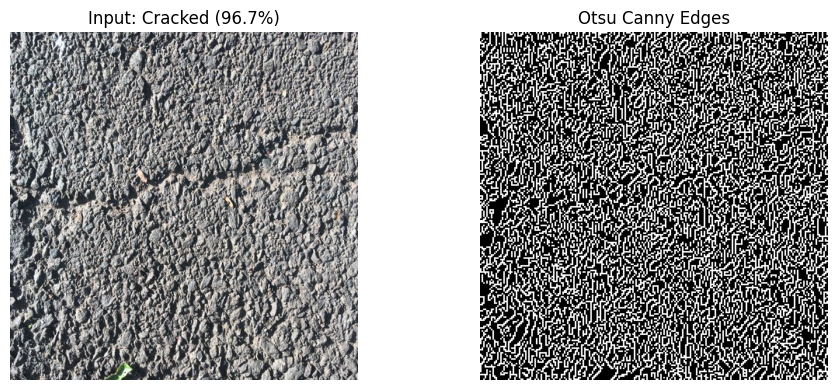

In [4]:
import os
import joblib
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew

# ==========================================
# 1. SPECIFY YOUR IMAGE PATH HERE
# ==========================================
IMAGE_PATH = "Cracks\\IMG_8429 resized_448.jpg"  # <-- Update this with your test image path

# ==========================================
# 2. CONFIGURATION & PATHS
# ==========================================
IMG_SIZE = (224, 224)
MODEL_PATH = "optimized_crack_classifier.pkl"
SCALER_PATH = "scaler_optimized.pkl"

# ==========================================
# 3. FEATURE EXTRACTION
# ==========================================
def extract_features(img_path):
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Could not load image at '{img_path}'. Check path and permissions.")

    # Resize & convert to Grayscale
    resized_img = cv2.resize(img, IMG_SIZE)
    gray = cv2.cvtColor(resized_img, cv2.COLOR_BGR2GRAY)
    total_pixels = gray.size

    # Numerical intensity features
    mean_brightness = float(np.mean(gray))
    contrast = float(np.std(gray))
    skewness = float(skew(gray.ravel()))
    dark_pixel_ratio = float(np.sum(gray < 60) / total_pixels)
    bright_pixel_ratio = float(np.sum(gray > 190) / total_pixels)
    median_val = float(np.median(gray))

    # Bilateral Filter + Otsu Canny Edge Detection
    filtered = cv2.bilateralFilter(gray, d=7, sigmaColor=50, sigmaSpace=50)
    otsu_thresh, _ = cv2.threshold(filtered, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    lower_thresh = int(max(10, 0.5 * otsu_thresh))
    upper_thresh = int(min(250, otsu_thresh))

    edges = cv2.Canny(filtered, lower_thresh, upper_thresh)
    edge_pixel_count = int(np.count_nonzero(edges))
    edge_density = float(edge_pixel_count / total_pixels)

    features = [
        mean_brightness,
        contrast,
        skewness,
        dark_pixel_ratio,
        bright_pixel_ratio,
        median_val,
        edge_pixel_count,
        edge_density
    ]
    return np.array(features).reshape(1, -1), img, edges

# ==========================================
# 4. INFERENCE & VISUALIZATION
# ==========================================
def predict_and_display(image_path):
    if not os.path.exists(MODEL_PATH) or not os.path.exists(SCALER_PATH):
        raise FileNotFoundError(
            f"Artifacts missing. Ensure '{MODEL_PATH}' and '{SCALER_PATH}' exist in your working directory."
        )

    # Load artifacts
    model = joblib.load(MODEL_PATH)
    scaler = joblib.load(SCALER_PATH)

    # Extract features
    raw_features, original_bgr, edges = extract_features(image_path)
    scaled_features = scaler.transform(raw_features)

    # Predict
    pred_class = model.predict(scaled_features)[0]
    
    confidence = None
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(scaled_features)[0]
        confidence = probs[pred_class] * 100

    label_map = {1: "Cracked", 0: "Non-Cracked"}
    pred_label = label_map.get(pred_class, "Unknown")

    # Output text results
    print("=" * 45)
    print(f"Target Image:      {image_path}")
    print(f"Predicted Class:   {pred_label}")
    if confidence is not None:
        print(f"Confidence:        {confidence:.2f}%")
    print("=" * 45)

    # Inline display for Jupyter Notebook
    original_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(original_rgb)
    axes[0].set_title(f"Input: {pred_label}" + (f" ({confidence:.1f}%)" if confidence else ""))
    axes[0].axis('off')

    axes[1].imshow(edges, cmap='gray')
    axes[1].set_title("Otsu Canny Edges")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# Run inference
predict_and_display(IMAGE_PATH)

Target Image:      Cracks\IMG_8429 resized_448.jpg
Predicted Class:   Cracked
Confidence:        96.67%

--- Extracted Feature Vector Table ---


,Feature Name,Raw Value,Scaled Value
0,Mean Brightness,123.7907,-1.4891
1,Contrast (Std Dev),54.2381,3.4574
2,Skewness,0.0030,-0.1478
3,Dark-Pixel Ratio,0.1719,9.1820
4,Bright-Pixel Ratio,0.1255,0.3094
5,Median Value,126.0000,-1.3646
6,Edge Pixel Count,18377.0000,2.9805
7,Edge Density,0.3663,2.9805


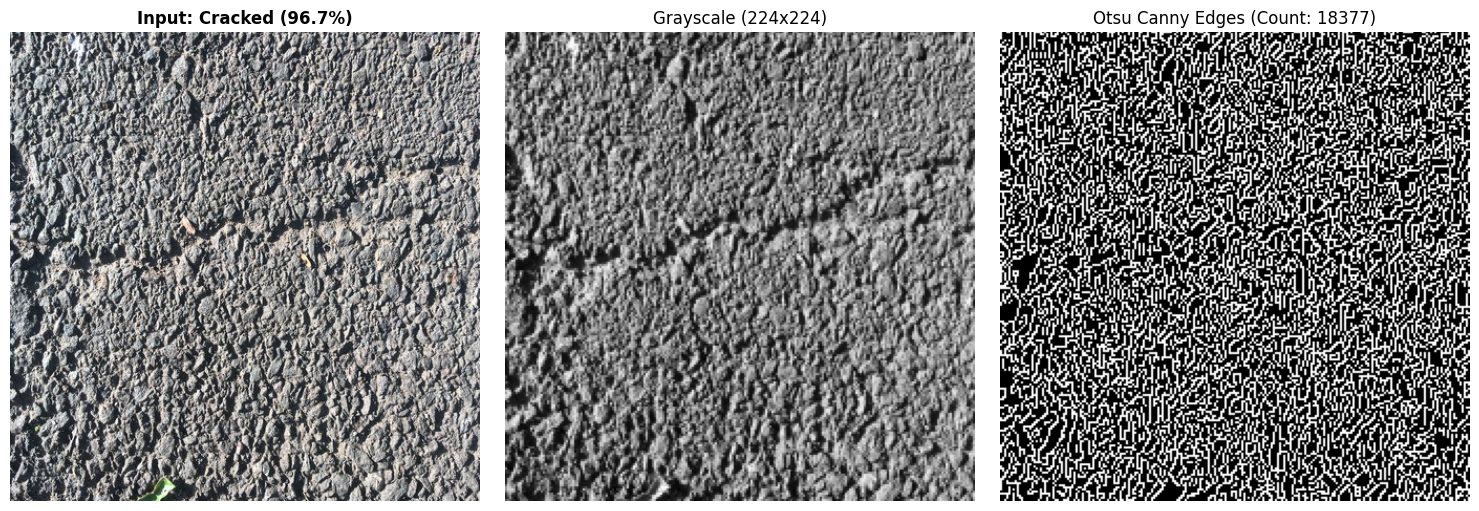

In [7]:
import os
import joblib
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew

# ==========================================
# 1. SPECIFY YOUR IMAGE PATH HERE
# ==========================================
IMAGE_PATH = "Cracks\\IMG_8429 resized_448.jpg"  

# ==========================================
# 2. CONFIGURATION & PATHS
# ==========================================
IMG_SIZE = (224, 224)
MODEL_PATH = "optimized_crack_classifier.pkl"
SCALER_PATH = "scaler_optimized.pkl"

FEATURE_NAMES = [
    "Mean Brightness",
    "Contrast (Std Dev)",
    "Skewness",
    "Dark-Pixel Ratio",
    "Bright-Pixel Ratio",
    "Median Value",
    "Edge Pixel Count",
    "Edge Density"
]

# ==========================================
# 3. FEATURE EXTRACTION
# ==========================================
def extract_features(img_path):
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Could not load image at '{img_path}'. Check path and permissions.")

    # Resize & convert to Grayscale
    resized_img = cv2.resize(img, IMG_SIZE)
    gray = cv2.cvtColor(resized_img, cv2.COLOR_BGR2GRAY)
    total_pixels = gray.size

    # Numerical intensity features
    mean_brightness = float(np.mean(gray))
    contrast = float(np.std(gray))
    skewness = float(skew(gray.ravel()))
    dark_pixel_ratio = float(np.sum(gray < 60) / total_pixels)
    bright_pixel_ratio = float(np.sum(gray > 190) / total_pixels)
    median_val = float(np.median(gray))

    # Bilateral Filter + Otsu Canny Edge Detection
    filtered = cv2.bilateralFilter(gray, d=7, sigmaColor=50, sigmaSpace=50)
    otsu_thresh, _ = cv2.threshold(filtered, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    lower_thresh = int(max(10, 0.5 * otsu_thresh))
    upper_thresh = int(min(250, otsu_thresh))

    edges = cv2.Canny(filtered, lower_thresh, upper_thresh)
    edge_pixel_count = int(np.count_nonzero(edges))
    edge_density = float(edge_pixel_count / total_pixels)

    features = [
        mean_brightness,
        contrast,
        skewness,
        dark_pixel_ratio,
        bright_pixel_ratio,
        median_val,
        edge_pixel_count,
        edge_density
    ]
    return np.array(features).reshape(1, -1), img, gray, edges

# ==========================================
# 4. INFERENCE, TABLE & VISUALIZATION
# ==========================================
def predict_and_display(image_path):
    if not os.path.exists(MODEL_PATH) or not os.path.exists(SCALER_PATH):
        raise FileNotFoundError(
            f"Artifacts missing. Ensure '{MODEL_PATH}' and '{SCALER_PATH}' exist in your working directory."
        )

    # Load artifacts
    model = joblib.load(MODEL_PATH)
    scaler = joblib.load(SCALER_PATH)

    # Extract features
    raw_features, original_bgr, gray, edges = extract_features(image_path)
    scaled_features = scaler.transform(raw_features)

    # Predict
    pred_class = model.predict(scaled_features)[0]
    
    confidence = None
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(scaled_features)[0]
        confidence = probs[pred_class] * 100

    label_map = {1: "Cracked", 0: "Non-Cracked"}
    pred_label = label_map.get(pred_class, "Unknown")

    # Output text summary
    print("=" * 55)
    print(f"Target Image:      {image_path}")
    print(f"Predicted Class:   {pred_label}")
    if confidence is not None:
        print(f"Confidence:        {confidence:.2f}%")
    print("=" * 55)

    # Create & display Extracted Image-Feature Table
    df_features = pd.DataFrame({
        "Feature Name": FEATURE_NAMES,
        "Raw Value": raw_features[0],
        "Scaled Value": scaled_features[0]
    })
    
    # Format raw and scaled outputs for clean display
    df_features["Raw Value"] = df_features["Raw Value"].apply(lambda v: f"{v:.4f}" if isinstance(v, float) else f"{v}")
    df_features["Scaled Value"] = df_features["Scaled Value"].apply(lambda v: f"{v:.4f}")

    print("\n--- Extracted Feature Vector Table ---")
    display(df_features)

    # Visualizations: Input Image, Grayscale, and Canny Edges
    original_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(original_rgb)
    title_suffix = f" ({confidence:.1f}%)" if confidence else ""
    axes[0].set_title(f"Input: {pred_label}{title_suffix}", fontsize=12, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(gray, cmap='gray')
    axes[1].set_title("Grayscale (224x224)", fontsize=12)
    axes[1].axis('off')

    axes[2].imshow(edges, cmap='gray')
    axes[2].set_title(f"Otsu Canny Edges (Count: {int(raw_features[0][6])})", fontsize=12)
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# Run inference
predict_and_display(IMAGE_PATH)

**Loading, training and evaluating text model based on CountVectorizer**

In [3]:
import re
import time
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

# 1. Load dataset
df = pd.read_csv("emails.csv")

# 2. Inspect class distribution (target column is 'Prediction')
print("--- Spam / Non-Spam Distribution ---")
print(df["Prediction"].value_counts())
print("\n--- Percentage Distribution ---")
print(df["Prediction"].value_counts(normalize=True) * 100)

# 3. Reconstruct text from the pre-extracted word columns
feature_words = [
    col for col in df.columns if col not in ["Email No.", "Prediction"]
]
words_array = np.array(feature_words)
counts_matrix = df[feature_words].values

df["email_text"] = [
    " ".join(np.repeat(words_array[row > 0], row[row > 0]))
    for row in counts_matrix
]


# Basic text cleaning
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


df["cleaned_text"] = df["email_text"].apply(clean_text)

# Train/Test Split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df["cleaned_text"],
    df["Prediction"],
    test_size=0.2,
    random_state=42,
    stratify=df["Prediction"],
)

# 4. Text Vectorization using CountVectorizer:
# Representation 1: Word Count / Term Frequency (binary=False)
# Representation 2: Binary Word Occurrence (binary=True)
representations = {
    "CountVectorizer (Term Frequencies)": CountVectorizer(binary=False),
    "CountVectorizer (Binary Occurrence)": CountVectorizer(binary=True),
}

comparison_results = []

for name, vec in representations.items():
    # Vectorize
    X_train = vec.fit_transform(X_train_raw)
    X_test = vec.transform(X_test_raw)

    num_features = X_train.shape[1]

    # Model training
    model = MultinomialNB()

    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train

    # Inference / Prediction
    start_pred = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - start_pred

    acc = accuracy_score(y_test, y_pred)

    comparison_results.append(
        {
            "Representation": name,
            "Number of Features": num_features,
            "Accuracy": round(acc, 4),
            "Training Time (s)": round(train_time, 5),
            "Prediction Time (s)": round(pred_time, 5),
        }
    )

    print(
        f"\n================ Classification Report: {name} ================"
    )
    print(
        classification_report(
            y_test, y_pred, target_names=["Non-Spam (0)", "Spam (1)"]
        )
    )

# 5. Compare performance, feature count, training time, and prediction time
comparison_df = pd.DataFrame(comparison_results)
print("\n================ Model & Representation Comparison ================")
print(comparison_df.to_string(index=False))

--- Spam / Non-Spam Distribution ---
Prediction
0    3672
1    1500
Name: count, dtype: int64

--- Percentage Distribution ---
Prediction
0    70.99768
1    29.00232
Name: proportion, dtype: float64

================ Classification Report: CountVectorizer (Term Frequencies) ================
              precision    recall  f1-score   support

Non-Spam (0)       0.98      0.94      0.96       735
    Spam (1)       0.87      0.94      0.90       300

    accuracy                           0.94      1035
   macro avg       0.92      0.94      0.93      1035
weighted avg       0.94      0.94      0.94      1035


================ Classification Report: CountVectorizer (Binary Occurrence) ================
              precision    recall  f1-score   support

Non-Spam (0)       0.98      0.93      0.96       735
    Spam (1)       0.85      0.95      0.90       300

    accuracy                           0.94      1035
   macro avg       0.92      0.94      0.93      1035
weighted avg   

**Loading, training and evaluating text model based on Optimized CountVectorizer**

In [4]:
import re
import time
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Normalizer
from sklearn.svm import LinearSVC

# ==========================================
# 1. Load Dataset & Inspect Distribution
# ==========================================
df = pd.read_csv("emails.csv")

print("--- Class Distribution ---")
print(df["Prediction"].value_counts())
print("\n--- Class Distribution (%) ---")
print((df["Prediction"].value_counts(normalize=True) * 100).round(2))

# ==========================================
# 2. Text Reconstruction & Cleaning
# ==========================================
feature_words = [
    col for col in df.columns if col not in ["Email No.", "Prediction"]
]
words_array = np.array(feature_words)
counts_matrix = df[feature_words].values

# Rebuild original email strings from token frequency rows
df["email_text"] = [
    " ".join(np.repeat(words_array[row > 0], row[row > 0]))
    for row in counts_matrix
]


def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


df["cleaned_text"] = df["email_text"].apply(clean_text)

# Train/Test Split (80/20 stratified)
X_train, X_test, y_train, y_test = train_test_split(
    df["cleaned_text"],
    df["Prediction"],
    test_size=0.2,
    random_state=42,
    stratify=df["Prediction"],
)

# ==========================================
# 3. Pipelines: Baseline vs. Optimized
# ==========================================
pipelines = {
    # Baseline: Vanilla CountVectorizer + MultinomialNB
    "Baseline (Vanilla CV + MNB)": Pipeline([("cv", CountVectorizer())]),
    # Optimized 1: Stop-words + Vocab Limits + N-grams + MNB
    "Optimized MNB (Stopwords + (1,2) N-Grams + Vocab Limit)": Pipeline(
        [
            (
                "cv",
                CountVectorizer(
                    stop_words="english",
                    ngram_range=(1, 2),
                    min_df=2,
                    max_df=0.95,
                    max_features=2500,
                ),
            )
        ]
    ),
    # Optimized 2: Stop-words + Vocab Limits + N-grams + L2 Norm + LinearSVC
    "Optimized LinearSVC (Stopwords + (1,2) N-Grams + L2 Norm + SVM)": Pipeline(
        [
            (
                "cv",
                CountVectorizer(
                    stop_words="english",
                    ngram_range=(1, 2),
                    min_df=2,
                    max_df=0.95,
                    max_features=2500,
                ),
            ),
            ("norm", Normalizer(norm="l2")),
        ]
    ),
}

# Corresponding models for each pipeline
models = {
    "Baseline (Vanilla CV + MNB)": MultinomialNB(),
    "Optimized MNB (Stopwords + (1,2) N-Grams + Vocab Limit)": MultinomialNB(),
    "Optimized LinearSVC (Stopwords + (1,2) N-Grams + L2 Norm + SVM)": LinearSVC(
        dual="auto", C=1.0, random_state=42
    ),
}

# ==========================================
# 4. Evaluation & Comparison
# ==========================================
benchmark_results = []

for name, pipe in pipelines.items():
    clf = models[name]

    # Feature extraction
    X_train_trans = pipe.fit_transform(X_train)
    X_test_trans = pipe.transform(X_test)
    num_features = pipe.named_steps["cv"].get_feature_names_out().shape[0]

    # Training time
    t_start = time.perf_counter()
    clf.fit(X_train_trans, y_train)
    train_time = time.perf_counter() - t_start

    # Prediction time (inference)
    t_start = time.perf_counter()
    y_pred = clf.predict(X_test_trans)
    pred_time = time.perf_counter() - t_start

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    benchmark_results.append(
        {
            "Pipeline": name,
            "Vocab Size": num_features,
            "Accuracy": round(acc, 4),
            "F1-Score": round(f1, 4),
            "Train Time (ms)": round(train_time * 1000, 2),
            "Inference Time (ms)": round(pred_time * 1000, 2),
        }
    )

    print(f"\n{'='*25} {name} {'='*25}")
    print(
        classification_report(
            y_test, y_pred, target_names=["Ham (0)", "Spam (1)"]
        )
    )

# Summary table
results_df = pd.DataFrame(benchmark_results)
print("\n" + "=" * 70)
print("FINAL BENCHMARK COMPARISON")
print("=" * 70)
print(results_df.to_string(index=False))

--- Class Distribution ---
Prediction
0    3672
1    1500
Name: count, dtype: int64

--- Class Distribution (%) ---
Prediction
0    71.0
1    29.0
Name: proportion, dtype: float64

========================= Baseline (Vanilla CV + MNB) =========================
              precision    recall  f1-score   support

     Ham (0)       0.98      0.94      0.96       735
    Spam (1)       0.87      0.94      0.90       300

    accuracy                           0.94      1035
   macro avg       0.92      0.94      0.93      1035
weighted avg       0.94      0.94      0.94      1035


========================= Optimized MNB (Stopwords + (1,2) N-Grams + Vocab Limit) =========================
              precision    recall  f1-score   support

     Ham (0)       0.98      0.93      0.96       735
    Spam (1)       0.85      0.96      0.90       300

    accuracy                           0.94      1035
   macro avg       0.92      0.95      0.93      1035
weighted avg       0.94      0.

**Prediction of spam vs non-spam on actual text**

In [6]:
import re
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Normalizer
from sklearn.svm import LinearSVC

# 1. Load dataset & reconstruct cleaned training texts
df = pd.read_csv("emails.csv")
feature_words = [
    col for col in df.columns if col not in ["Email No.", "Prediction"]
]
words_array = np.array(feature_words)
counts_matrix = df[feature_words].values


def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


raw_texts = [
    " ".join(np.repeat(words_array[row > 0], row[row > 0]))
    for row in counts_matrix
]
df["cleaned_text"] = [clean_text(t) for t in raw_texts]

# 2. Build and train the optimized pipeline (CountVectorizer + L2 Norm + LinearSVC)
pipeline = Pipeline(
    [
        (
            "cv",
            CountVectorizer(
                stop_words="english",
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                max_features=2500,
            ),
        ),
        ("norm", Normalizer(norm="l2")),
        ("clf", LinearSVC(dual="auto", C=1.0, random_state=42)),
    ]
)

pipeline.fit(df["cleaned_text"], df["Prediction"])

# 3. Fixed input text for inference
input_text = "Congratulations! You have won a free $1,000 cash prize. Click the link below to claim your reward immediately."

# 4. Clean and predict
cleaned_input = clean_text(input_text)
prediction = pipeline.predict([cleaned_input])[0]
label_mapping = {0: "Non-Spam (Ham)", 1: "Spam"}

# 5. Output result
print(f"Input Text: {input_text}")
print(f"Prediction: {label_mapping[prediction]} (Class {prediction})")

Input Text: Congratulations! You have won a free $1,000 cash prize. Click the link below to claim your reward immediately.
Prediction: Spam (Class 1)
